## Machine Learning : Theory and Applications (2025/26)
Simona Cocco & Vito Dichio

[✉ simona.cocco@phys.ens.fr](mailto:simona.cocco@phys.ens.fr) \\
[✉ vito.dichio@phys.ens.fr](mailto:vito.dichio@phys.ens.fr)


#### Bibliography:

[1] Cocco et al., *From Statistical Physics to Data-Driven Modelling: with Applications to Quantitative Biology*, Oxford University Press (2022) -- Sec. 8.2

[2] Jurafsky & Martin, *Hidden Markov Models*, from *Speech and Language Processing*. Draft of August 24, 2025. Available [here](https://web.stanford.edu/~jurafsky/slp3/A.pdf)

[3] Bishop, *Pattern Recognition and Machine Learning*, Springer (2006) -- Sec. 13.2

[4] Karpenko et al., *From behavior to circuit modeling of light-seeking navigation in zebrafish larvae*, eLife 9, e52882 (2020)

# ML for Neuroscience — Tutorial 5 (SOLUTION)

#### **Topic:** Hidden Markov Models for Behavioral Analysis

#### 🎯 **Goals**

- Understand the structure and components of Hidden Markov Models (HMMs)
- Apply HMMs to infer hidden behavioral states from observed data
- Analyze zebrafish swimming behavior using HMMs

## Hidden Markov Models

A **Hidden Markov Model (HMM)** is a statistical model used to describe systems that evolve over time with two key characteristics:

1. **Hidden states**: The system is in one of several discrete states at each time step, but we cannot directly observe which state it's in
2. **Observable emissions**: At each time step, the hidden state generates an observable output according to some probability distribution

**Formal definition**: An HMM is defined by
- A set of **hidden states** $\{x_1, x_2, \ldots, x_D\}$
- **Transition probabilities** $\Omega(x \rightarrow x^\prime)$: probability of moving from one state to another
- **Emission probabilities** $\mathcal{E}(y\ |\ x)$: probability of observing output $y$ given hidden state $x$

#### The Markov Property

The model assumes the **Markov property**: the future is independent of the past given the present. Mathematically:
$$P(x_t | x_{t-1}, x_{t-2}, \ldots, x_1) = P(x_t | x_{t-1})$$

This means the probability of being in a state at time $t$ depends only on the state at time $t-1$, not on the entire history.

#### The Three Fundamental Problems of HMMs

Given an HMM with known parameters, there are three fundamental questions we might want to answer. Given a sequence of observations $\mathbf{y} = (y_1, y_2, \ldots, y_T)$:

1. What is the probability that the model generated this sequence? (**Likelihood Problem**)

2. What is the most likely sequence of hidden states $\mathbf{x}^* = (x_1^*, x_2^*, \ldots, x_T^*)$? (**Decoding Problem**)

3. How do we estimate the model parameters $\Omega$ and $\mathcal{E}$? (**Learning Problem**)

In this tutorial, **we focus on the decoding problem**: inferring the most likely sequence of hidden states given observations. We will use the **Viterbi algorithm** to decode zebrafish swimming behavior from observed bout angles.

## Case Study: Zebrafish Swimming Behavior

### Biological Context

**Zebrafish larvae** are a model organism widely used in neuroscience research because their brains are relatively simple (~100,000 neurons) and their behavior is stereotyped and quantifiable. When swimming freely, zebrafish larvae exhibit discrete **swimming bouts** - brief episodes of tail movement that propel the fish through water. Between bouts, the fish glides or remains stationary.

Karpenko+ [4] focused on three main types of swimming bouts in zebrafish larvae: the **forward (F)** the fish swims straight ahead with minimal change in heading direction, the **left turn (L)** where the fish turns to the left, and the **right turn (R)** where the fish turns to the right. These bout types represent **hidden states** -- we cannot directly measure the fish's "intention" to go forward or turn, but we can observe the **consequences** of these decisions.

More precisely, we can observe at each time step the **change in heading angle** (or orientation) $\delta\alpha$ (in radians): small angles indicate forward movement, while larger positive or negative angles indicate right or left turns, respectively. However, there is **noise and variability**: forward bouts sometimes result in small deviations, turn bouts vary in magnitude and there may be measurement errors. This is precisely the situation where an HMM excels: we have noisy observations (variations of the orientation) and want to infer the underlying discrete decisions (F, L, or R).

Note: Karpenko et al. use a clockwise sign convention for heading changes: $\delta\alpha$ is negative for a left turn, positive for a right turn (see Fig. 1b).  Heading angles are recorded immediately before each bout, so `delta_alpha_t = alpha_{t+1} - alpha_{t}` (the last bout of each trajectory has no `delta_alpha`).

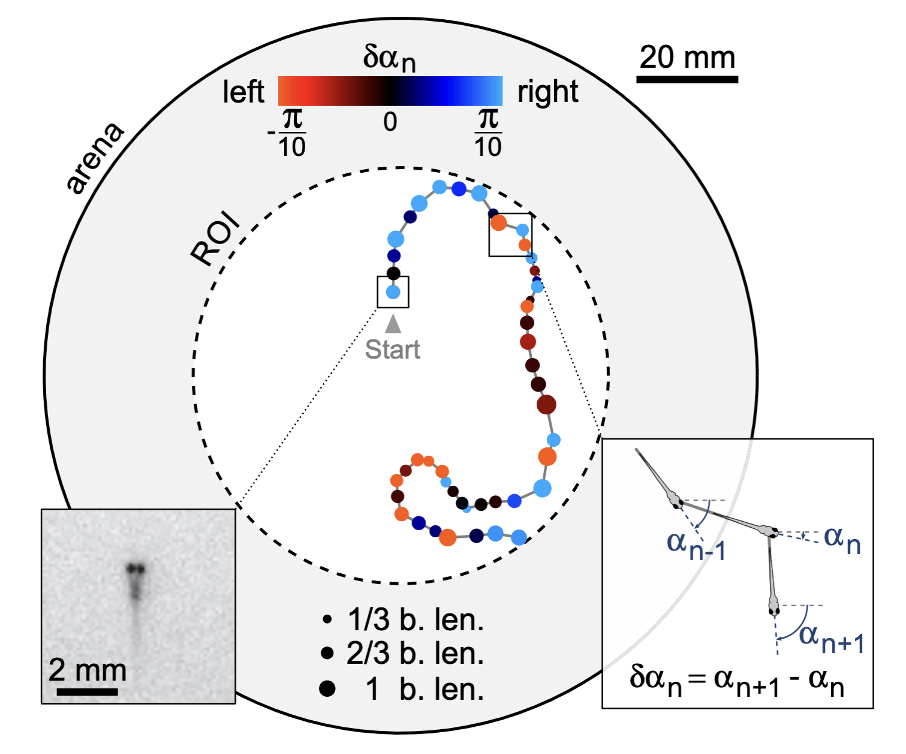

In [1]:
from IPython.display import Image
Image("bibliography/karpenko+2020-1b.png", width=500)

### The HMM Structure for Zebrafish

#### Hidden States

We model zebrafish swimming as an HMM with **three hidden states**:
- **Forward (F)**: Swimming straight ahead
- **Left turn (L)**: Turning left
- **Right turn (R)**: Turning right

These states represent the fish's underlying behavioral decision at each time step, which we cannot directly observe.

#### Transition Probabilities

The transition matrix $\Omega$ describes how the fish switches between behaviors. By symmetry (left and right are equivalent in unbiased swimming), we can parameterize transitions using two probabilities:

- $p_{\text{turn}}$: probability of initiating a turn (vs. continuing forward)
- $p_{\text{flip}}$: probability of reversing turn direction

This gives:
$$\Omega = \begin{pmatrix}
P(F \to F) & P(F \to L) & P(F \to R) \\
P(L \to F) & P(L \to L) & P(L \to R) \\
P(R \to F) & P(R \to L) & P(R \to R)
\end{pmatrix} = \begin{pmatrix}
1 - p_{\text{turn}} & p_{\text{turn}}/2 & p_{\text{turn}}/2 \\
1 - p_{\text{turn}} & p_{\text{turn}}(1-p_{\text{flip}}) & p_{\text{turn}} \ p_{\text{flip}} \\
1 - p_{\text{turn}} & p_{\text{turn}} \ p_{\text{flip}} & p_{\text{turn}}(1-p_{\text{flip}})
\end{pmatrix}$$

#### Emission Probabilities

Each hidden state generates observed angles according to a characteristic distribution:

- **Forward bouts**: Small angles centered at zero
$$\mathcal{E}(\delta\alpha | F) = \mathcal{N}(\delta\alpha; 0, \sigma_F)$$

- **Left turn bouts**: Negative angles only (truncated Gaussian)
$$\mathcal{E}(\delta\alpha | L) = \begin{cases}
2\mathcal{N}(\delta\alpha; 0, \sigma_T) & \text{if } \delta\alpha < 0 \\
0 & \text{if } \delta\alpha \geq 0
\end{cases}$$

- **Right turn bouts**: Positive angles only (truncated Gaussian)
$$\mathcal{E}(\delta\alpha | R) = \begin{cases}
2\mathcal{N}(\delta\alpha; 0, \sigma_T) & \text{if } \delta\alpha > 0 \\
0 & \text{if } \delta\alpha \leq 0
\end{cases}$$

where $\mathcal{N}(x; 0, \sigma) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-x^2/(2\sigma^2)}$ is the Gaussian (normal) distribution with zero mean and standard deviation $\sigma$. The factor of 2 in the truncated distributions ensures proper normalization.

#### Model Parameters

Based on empirical analysis by Karpenko+ [4], the following parameters were estimated from zebrafish behavioral data:

- $\sigma_F = 0.1$ rad: forward bouts have small angular variability (~5.7°)
- $\sigma_T = 0.6$ rad: turn bouts have larger angular variability (~34.4°)
- $p_{\text{turn}} = 0.41$: fish initiate turns about 41% of the time
- $p_{\text{flip}} = 0.19$: fish reverse turn direction about 19% of the time

**These values will be used throughout the tutorial.** There is no need to re-estimate them (Learning problem). The parameters and the transition matrix are defined below for later use.

In [2]:
import numpy as np

# Parameters from Karpenko et al.
p_turn = 0.41
p_flip = 0.19
sigma_F = 0.1  # rad
sigma_T = 0.6  # rad

# Define transition matrix Ω
omega = np.array([
    # Row 0: transitions FROM Forward
    [1 - p_turn,              p_turn/2,                 p_turn/2],
    # Row 1: transitions FROM Left
    [1 - p_turn,              p_turn*(1-p_flip),    p_turn*p_flip],
    # Row 1: transitions FROM Right
    [1 - p_turn,              p_turn*p_flip,          p_turn*(1-p_flip)]
])

# name mappings for states
state_names = np.array(['F', 'L', 'R'])
# color mappings for states
state_colors = ['#7d7d7d', '#cc3333', '#005a8c']

### Data Structure

The dataset contains recordings from **523 individual zebrafish larvae**, each recorded over a sequence of discrete swimming bouts. All per-bout observations are stored together in a **single pandas DataFrame** where each row corresponds to one bout event.

The DataFrame includes the following columns:

| Column     | Description                                                    |
|------------|----------------------------------------------------------------|
| `fish_idx` | Identifier for the fish (0–522)                                |
| `t_bout`   | Time of bout occurrence (seconds; NaN if unavailable)          |
| `x`, `y`   | Spatial coordinates in millimeters                             |
| `alpha`    | Absolute heading angle (radians)                               |

**Key properties**
- Different fish have **different numbers of bouts** (variable-length time series)
- Data for all fish is **stacked vertically** (not separate tables)
- Heading angle change can be computed per fish as $\delta \alpha_t = \alpha_t - \alpha_{t-1}$
  so each fish has **one fewer** delta-angle value than bouts

To work with a specific fish -- es. `fish_id = 0` -- use `fish_df = full_df[full_df.fish_idx == fish_id]`


In [3]:
import h5py, os
import numpy as np
import pandas as pd

def extract_fish_dfs(mat_path: str, dropna: bool = True, verbose: bool = True) -> pd.DataFrame:
    """
    Efficiently extract per-bout observations for ALL fish in a MATLAB .mat HDF5 file
    and combine into a single long-format DataFrame.

    Columns: ['fish_idx', 't_bout', 'x', 'y', 'alpha']
    """

    def find_dataset(f, target_suffix: str):
        matches = []
        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset) and name.endswith(target_suffix):
                matches.append(name)
        f.visititems(visitor)
        return matches[0] if matches else None

    if verbose:
        print("Opening HDF5 .mat file...")

    with h5py.File(mat_path, 'r') as f:

        angle_path = find_dataset(f, 'Angle')
        time_path  = find_dataset(f, 'TimeBout') or find_dataset(f, 'Time') or find_dataset(f, 'BoutTime')
        x_path     = find_dataset(f, 'Coordinates/x') or find_dataset(f, 'x') or find_dataset(f, 'Coord_x')
        y_path     = find_dataset(f, 'Coordinates/y') or find_dataset(f, 'y') or find_dataset(f, 'Coord_y')

        if angle_path is None:
            raise KeyError("Missing 'Angle' dataset!")

        # Read once
        angle_arr = f[angle_path][()]
        t_arr = f[time_path][()] if time_path else np.full_like(angle_arr, np.nan)
        x_arr = f[x_path][()] if x_path else np.full_like(angle_arr, np.nan)
        y_arr = f[y_path][()] if y_path else np.full_like(angle_arr, np.nan)

        # Normalize shape
        if angle_arr.ndim == 1:
            angle_arr = angle_arr.reshape(-1, 1)

        n_rows, n_fish = angle_arr.shape
        if verbose:
            print(f"Detected dataset: {n_rows} rows × {n_fish} columns")

        mm = 1 / 11.5  # px → mm conversion

        all_rows = []

        for fish_idx in range(n_fish):
            alpha = angle_arr[:, fish_idx]
            t = t_arr[:, fish_idx] if t_arr.ndim == 2 else t_arr
            x = (x_arr[:, fish_idx] if x_arr.ndim == 2 else x_arr) * mm
            y = (y_arr[:, fish_idx] if y_arr.ndim == 2 else y_arr) * mm

            df = pd.DataFrame({
                "fish_idx": fish_idx,
                "t_bout": t,
                "x": x,
                "y": y,
                "alpha": alpha
            })

            if dropna:
                df = df.dropna(how='all', subset=["t_bout", "x", "y", "alpha"])

            all_rows.append(df)

    # Combine everything
    full_df = pd.concat(all_rows, ignore_index=True)

    if verbose:
        print(f"\nFinal dataset size: {len(full_df)} rows.")
        print("Finished extracting all fish.\n")

    return full_df

data_path = os.path.join('data', 'spontaneous_swim.mat')

fish_bouts = extract_fish_dfs(data_path)
print(fish_bouts.head())

Opening HDF5 .mat file...
Detected dataset: 1436 rows × 523 columns

Final dataset size: 16147 rows.
Finished extracting all fish.

   fish_idx    t_bout          x          y     alpha
0         0  0.188173  37.304348  63.478261  2.176144
1         0  0.752694  34.434783  59.565217  2.116500
2         0  1.236568  30.956522  54.260870  2.094446
3         0  1.801088  27.391304  48.869565  2.149090
4         0  2.419372  25.391304  43.913043  1.878000


## 1 - Data exploration and preprocessing

Before implementing the Viterbi algorithm, we need to explore the data and verify that our HMM assumptions are reasonable by comparing observed angle distributions with the theoretical emission model.

### 🎯 Question 1a. Computing Angle Changes from Multiple Trajectories

The data has been loaded into a long-format DataFrame `fish_bouts` with columns `['fish_idx', 't_bout', 'x', 'y', 'alpha']`.

Create a function `collect_all_delta_alpha(fish_bouts)` that:
- Computes angle changes $\delta\alpha_t = \alpha_t - \alpha_{t-1}$ for each fish
- Handles the fact that the first bout of each fish has no previous angle
- Returns all angle changes concatenated into a single 1D array (NaN removed)

**Returns:**
- `all_delta_alpha`: 1D numpy array of all angle changes

Test your function and print the total number of observations collected.

💡 *Hints*:
- Use `groupby('fish_idx')` to process each fish separately [(documentation)](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.groupby.html)
- The `.diff()` method computes differences within each group [(documentation)](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.diff.html)
- Remember to remove NaN values (automatically created at group boundaries)

💡 *Remember*: Each trajectory has T bouts but only T-1 angle changes (we cannot compute $\delta\alpha$ for the first bout of each fish).

In [4]:
### Question 1a Solution

def collect_all_delta_alpha(fish_bouts) -> np.ndarray:
    """
    Collect angle changes from all fish trajectories.

    Parameters
    ----------
    fish_bouts : pd.DataFrame
        Long-format DataFrame with columns 'fish_idx' and 'alpha'.

    Returns
    -------
    np.ndarray
        1D array of all angle changes (NaN removed)
    """

    # compute per-fish differences in `alpha` (angle change between consecutive bouts)
    grouped = fish_bouts.groupby('fish_idx')['alpha']
    delta_alpha_series = grouped.diff()  # NaN for the first bout of each fish
    delta_alpha_clean = delta_alpha_series.dropna()  # remove NaNs introduced by group boundaries
    all_delta_alpha = delta_alpha_clean.to_numpy()  # final 1D numpy array

    return all_delta_alpha

all_delta_alpha = collect_all_delta_alpha(fish_bouts)

print(f"\nTotal number of observations: {len(all_delta_alpha)}")
print(f"Angle range: [{np.min(all_delta_alpha):.3f}, {np.max(all_delta_alpha):.3f}] rad")
print(f"Mean angle change: {np.mean(all_delta_alpha):.6f} rad (should be ≈0)")
print(f"Std angle change: {np.std(all_delta_alpha):.3f} rad")


Total number of observations: 15624
Angle range: [-2.957, 8.074] rad
Mean angle change: 0.004467 rad (should be ≈0)
Std angle change: 0.416 rad


### 🎯 Question 1b. Visualizing Data vs. Theory

Compare the observed angle distribution with the theoretical emission model. This corresponds to Figure 1D in Karpenko+ [4].

**Task:** Create a plot with:
1. **Histogram** of all observed $\delta\alpha$ values (use `density=True`)
2. **Theoretical mixture** overlaid as a curve

The **marginal distribution** of observed angles (averaging over hidden states) is:
$$P(\delta\alpha) = (1 - p_{\text{turn}}) \cdot \mathcal{N}(\delta\alpha; 0, \sigma_F) + p_{\text{turn}} \cdot \mathcal{N}(\delta\alpha; 0, \sigma_T)$$

According to this formula, with probability 59%, the fish goes forward (narrow peak); with probability 41%, it turns (wide distribution).

**Interpretation questions:**
1. Does the observed distribution match the theoretical mixture reasonably well?
2. Can you distinguish the narrow forward peak from the wider turn distribution?
3. Does the relative height of the peaks match the 59% forward / 41% turn split?

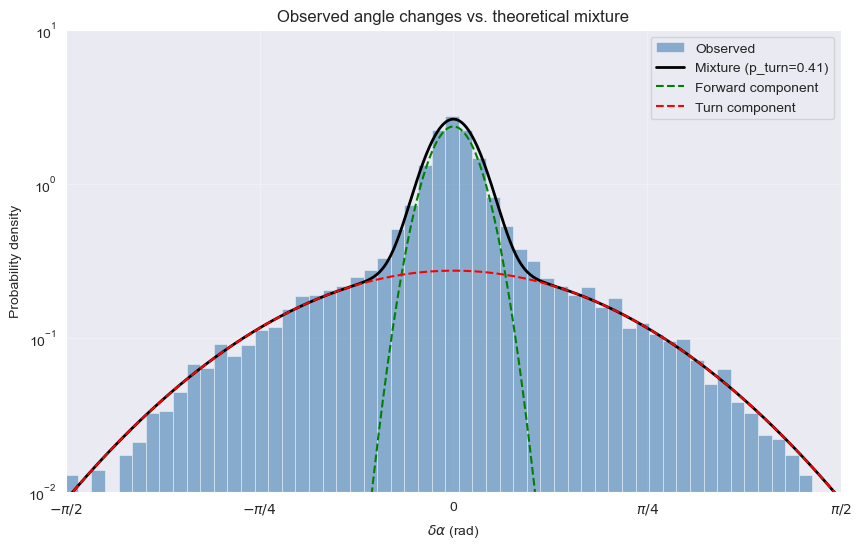

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def gaussian_mixture(x, sigma_F=sigma_F, sigma_T=sigma_T, p_turn=p_turn):
    """
    Weighted Gaussian mixture for forward vs turn components.

    Parameters
    ----------
    x : array-like
        Points at which to evaluate the densities (1D array).
    sigma_F : float
        Standard deviation of the forward (narrow) Gaussian. Must be > 0.
    sigma_T : float
        Standard deviation of the turn (wide) Gaussian. Must be > 0.
    p_turn : float
        Mixture weight for the turn component (0 <= p_turn <= 1).
        The forward component weight is (1 - p_turn).
    """

    x = np.asarray(x)
    if sigma_F <= 0 or sigma_T <= 0:
        raise ValueError("sigma_F and sigma_T must be positive.")
    if not (0.0 <= p_turn <= 1.0):
        raise ValueError("p_turn must be between 0 and 1.")

    gaussian_F = norm.pdf(x, loc=0, scale=sigma_F)
    gaussian_T = norm.pdf(x, loc=0, scale=sigma_T)
    mixture = (1.0 - p_turn) * gaussian_F + p_turn * gaussian_T

    return mixture, gaussian_F, gaussian_T


def plot_angle_distribution(data, mixture_func, n_bins=100):
    """
    Simple plot of observed angle-change histogram with theoretical mixture overlay.

    Parameters
    - data: 1D array-like of delta angles (NaNs ignored)
    - mixture_func: callable(x, sigma_F, sigma_T, p_turn) -> (mixture, gF, gT)
    - bins: number of histogram bins
    """
    arr = np.asarray(data).ravel()
    arr = arr[~np.isnan(arr)]
    if arr.size == 0:
        raise ValueError("`data` contains no valid values to plot.")

    angles = np.linspace(-np.pi/2, np.pi/2, 500)
    mixture, gF, gT = mixture_func(angles)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(arr, bins=n_bins, density=True, alpha=0.6,
            color='steelblue', edgecolor='white', linewidth=0.5, label='Observed')
    ax.plot(angles, mixture, 'k-', linewidth=2, label=f'Mixture (p_turn={p_turn})')
    ax.plot(angles, (1 - p_turn) * gF, 'g--', label='Forward component')
    ax.plot(angles, p_turn * gT, 'r--', label='Turn component')

    ax.set_yscale('log')
    ax.set_ylim(1e-2,1e1)

    ax.set_xlabel(r'$\delta\alpha$ (rad)')
    ax.set_ylabel('Probability density')
    ax.set_title('Observed angle changes vs. theoretical mixture')
    ax.set_xlim(-np.pi/2, np.pi/2)
    ax.set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
    ax.set_xticklabels([r'$-\pi/2$', r'$-\pi/4$', '0', r'$\pi/4$', r'$\pi/2$'])
    ax.grid(alpha=0.3)
    ax.legend()

    plt.show()
    return


plot_angle_distribution(all_delta_alpha, gaussian_mixture, n_bins=200)

## 2 - Implementing the Viterbi Algorithm

### 🎯 Question 2a. Preliminaries: computing Emission Probabilities

Before implementing Viterbi, we need a function to compute emission probabilities for all three states.

(i) Implement `compute_emission_probs(delta_alpha, sigma_F, sigma_T)` that:
- Takes an array of angle changes, shape `(T,)`
- Returns a matrix of emission probabilities, shape `(T, 3)`
- Row $t$ contains: $[\mathcal{E}(\delta\alpha_t|F), \mathcal{E}(\delta\alpha_t|L), \mathcal{E}(\delta\alpha_t|R)]$

Use the Gaussian probability density functions described in the introduction. For numerical stability, use a small value (e.g., `1e-12`) instead of exactly 0 for impossible emissions (e.g., negative angles for state L).

In [6]:
### Question 2a Solution

def compute_emission_probs(delta_alpha, sigma_F, sigma_T):
    """
    Compute emission probabilities for all three states.

    Parameters
    ----------
    delta_alpha : ndarray, shape (T,)
        Sequence of angle changes
    sigma_F : float
        Standard deviation for forward state
    sigma_T : float
        Standard deviation for turn states

    Returns
    -------
    emission_matrix : ndarray, shape (T, 3)
        Row t contains [P(δα_t|F), P(δα_t|L), P(δα_t|R)]
    """

    # Forward state: Gaussian centered at 0
    prob_F = norm.pdf(delta_alpha, loc=0, scale=sigma_F)

    # Left state: truncated Gaussian (negative angles only)
    prob_L = np.where(delta_alpha < 0, 2 * norm.pdf(delta_alpha, loc=0, scale=sigma_T), 1e-20)

    # Right state: truncated Gaussian (positive angles only)
    prob_R = np.where(delta_alpha > 0, 2 * norm.pdf(delta_alpha, loc=0, scale=sigma_T), 1e-20)

    # Stack into matrix with shape (T, 3)
    return np.stack([prob_F, prob_L, prob_R], axis=-1)


(ii) **Visualization:** Plot the three emission probability functions over the range $(-\pi, \pi)$ to verify correctness.

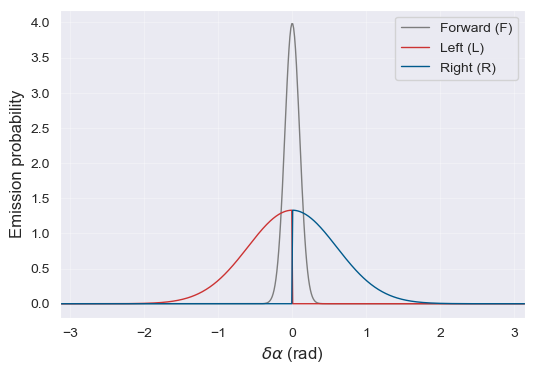

In [7]:
def plot_emission_functions(sigma_F, sigma_T, state_colors=state_colors):
    """
    Plot emission probability functions for states F, L, R.

    Parameters
    - sigma_F, sigma_T: standard deviations for forward and turn Gaussians

    """

    angles = np.linspace(-np.pi, np.pi, 500)

    # compute_emission_probs must be available in the calling scope
    emission_probs = compute_emission_probs(angles, sigma_F, sigma_T)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(angles, emission_probs[:, 0], c=state_colors[0], linewidth=1, label='Forward (F)')
    ax.plot(angles, emission_probs[:, 1], c=state_colors[1], linewidth=1, label='Left (L)')
    ax.plot(angles, emission_probs[:, 2], c=state_colors[2], linewidth=1, label='Right (R)')

    ax.set_xlabel(r'$\delta\alpha$ (rad)', fontsize=12)
    ax.set_ylabel('Emission probability', fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim(-np.pi, np.pi)

    plt.show()
    return

plot_emission_functions(sigma_F, sigma_T)

(iii) **Test:** Compute the emission probabilities for the angle changes of the first fish (`fish_idx=0`) and print the resulting emission matrix for the first 10 time steps. Verify that the most likely state matches the sign and magnitude of each angle change.

In [8]:
def get_fish_delta_alpha_array(fish_bouts, fish_idx):
    """
    Extract delta_alpha array for a specific fish.

    Parameters
    ----------
    fish_bouts : pd.DataFrame
        Long-format DataFrame with columns 'fish_idx' and 'alpha'.
    fish_idx : int
        Index of the fish to extract.

    Returns
    -------
    delta_alpha : ndarray, shape (T-1,)
        Array of angle changes for the specified fish.
    """

    df_fish = fish_bouts[fish_bouts.fish_idx == fish_idx]

    # .values to get numpy array, then np.diff to compute angle changes (no NaN issues here)
    delta_alpha = np.diff(df_fish['alpha'].values)

    return delta_alpha

delta_alpha_fish0 = get_fish_delta_alpha_array(fish_bouts, 0)
emission_matrix = compute_emission_probs(delta_alpha_fish0, sigma_F, sigma_T)

## Fancy display of first 10 emission probabilities
idx = np.arange(len(delta_alpha_fish0))

df_em = pd.DataFrame({
    'idx': idx,
    'delta_alpha': delta_alpha_fish0,
    'P(F)': emission_matrix[:, 0],
    'P(L)': emission_matrix[:, 1],
    'P(R)': emission_matrix[:, 2],
    'Likely': state_names[np.argmax(emission_matrix, axis=1)]
})

print("\nEmission probabilities for first 10 bouts of fish 0:")
print("=" * 75)
print(df_em.head(10).to_string(
    index=False,
    formatters={
        'delta_alpha': lambda x: f"{x:10.4f}",
        'P(F)':        lambda x: f"{x:10.6f}",
        'P(L)':        lambda x: f"{x:10.6f}",
        'P(R)':        lambda x: f"{x:10.6f}",
    }
))
print("=" * 75)


Emission probabilities for first 10 bouts of fish 0:
 idx delta_alpha       P(F)       P(L)       P(R) Likely
   0     -0.0596   3.339355   1.323253   0.000000      F
   1     -0.0221   3.893579   1.328910   0.000000      F
   2      0.0546   3.436144   0.000000   1.324304      F
   3     -0.2711   0.101180   1.200772   0.000000      L
   4      0.1818   0.764589   0.000000   1.270161      R
   5      0.1894   0.663229   0.000000   1.265153      R
   6     -0.0360   3.738479   1.327410   0.000000      F
   7      0.1905   0.649523   0.000000   1.264419      R
   8     -0.0105   3.967510   1.329604   0.000000      F
   9      0.0304   3.809641   0.000000   1.328105      F


### 🎯 Question 2b. Implementing the Viterbi Algorithm

The Viterbi algorithm finds the most likely sequence of hidden states given observed data using dynamic programming.

#### Algorithm Overview

The algorithm operates in two phases:

1. **Forward pass**: For each time step $t$ and state $x$, compute the maximum log-probability of any path ending in state $x$ at time $t$, and store which previous state achieved this maximum (backpointer).

2. **Backward pass**: Starting from the most likely final state, follow the backpointers to reconstruct the optimal path.

#### Mathematical Formulation

At each time step, we compute:

$$v_t(x_t) = \max_{x_{t-1}} \left[ v_{t-1}(x_{t-1}) + \log P(x_t | x_{t-1}) \right] + \log P(\delta\alpha_t | x_t)$$

where $v_t(x_t)$ is the maximum log-probability of any path ending in state $x_t$ at time $t$.

The logarithms are used to avoid that many small probabilities cause numerical underflow.

💡 **Key insight**: The emission term $\log P(\delta\alpha_t | x_t)$ depends only on the current state $x_t$, not on the previous state $x_{t-1}$. Therefore, when finding $\arg\max_{x_{t-1}}$ (the best previous state), we can **separate** the emission term:

1. Find the best previous state using only: $v_{t-1}(x_{t-1}) + \log P(x_t | x_{t-1})$
2. Then add the emission term: $+ \log P(\delta\alpha_t | x_t)$

This separation simplifies the computation and is reflected in the implementation below.

---

**Task:** Implement `viterbi(E, omega, initial_state=None)` that returns the most likely state sequence.

**Inputs:**
- `E`: emission probability matrix, shape `(T, n_states)` where `E[t, state]` = $P(\delta\alpha_t | \text{state})$
- `omega`: transition matrix, shape `(n_states, n_states)` where `omega[i, j]` = $P(x_{t+1}=j | x_t=i)$
- `initial_state`: starting state (0, 1, 2, ...) or `None` to auto-select based on first emission

**Output:**
- `states`: most likely state sequence, shape `(T,)` with values in {0, 1, ..., n_states-1}

**Algorithm structure:**

**Step 1: Initialize with first observation**

Instead of starting with a fixed initial state, we can incorporate the first observation directly:
```python
T, n_states = E.shape

if initial_state is None:
    # Choose best initial state based on first emission
    v = np.log(E[0, :])
else:
    # Force specific initial state
    v = np.full(n_states, -np.inf)
    v[initial_state] = np.log(E[0, initial_state])

backpointers = np.zeros((T, n_states), dtype=int)
```

**Step 2: Forward pass**

For each time $t = 1, 2, \ldots, T-1$ (starting from $t=1$ since $t=0$ is handled in initialization):
```python
for t in range(1, T):
    v_new = np.zeros(n_states)

    for next_state in range(n_states):
        # Find best previous state (emission term excluded from argmax)
        candidates = v + np.log(omega[:, next_state])
        best_prev = np.argmax(candidates)

        # Add emission term after finding best path
        v_new[next_state] = candidates[best_prev] + np.log(E[t, next_state])
        backpointers[t, next_state] = best_prev

    v = v_new
```

**Key difference from naive approach**: We compute `candidates` using only the transition probabilities, find `argmax`, then add the emission. This is mathematically equivalent but conceptually clearer.

**Step 3: Termination**

The final state is simply:
```python
final_state = np.argmax(v)
```

No need to add emissions again—they're already incorporated in `v`.

**Step 4: Backward pass**
```python
states = np.zeros(T, dtype=int)
states[T-1] = final_state

for t in range(T-2, -1, -1):
    states[t] = backpointers[t+1, states[t+1]]
```

**Analyze the results:**
1. Print state occupancy (percentage of time in each state)
2. Display the first 20 inferred states
3. Compare inferred states with observed angle signs
4. Test with `initial_state=None` vs `initial_state=0` - do results differ significantly?

**Expected behavior:**
- Forward state should dominate (~60-80% of time steps)
- You should observe **persistence**: consecutive time steps in the same state
- Starting with `initial_state=None` may give slightly different results for the first few time steps, but should converge quickly

In [9]:
def viterbi(E, omega, initial_state=None):
    """
    Viterbi algorithm for inferring the most likely hidden state sequence.

    The algorithm uses dynamic programming to find the state sequence that
    maximizes P(states | observations). All computations are performed in
    log-space to avoid numerical underflow.

    Parameters
    ----------
    E : ndarray, shape (T, n_states)
        Emission probability matrix where E[t, state] = P(obs_t | state).
        Each row contains emission probabilities for all states at time t.
    omega : ndarray, shape (n_states, n_states)
        Transition matrix where omega[i, j] = P(x_{t+1} = j | x_t = i).
        Element [i, j] is the probability of transitioning from state i to state j.
    initial_state : int or None, optional
        If specified, forces the sequence to start in this state.
        If None, the algorithm chooses the best initial state based on first emission.

    Returns
    -------
    states : ndarray, shape (T,)
        Most likely state sequence, with values in {0, 1, ..., n_states-1}

    Notes
    -----
    The algorithm computes v[t, x] = max log-probability of any path ending
    in state x at time t, along with backpointers to reconstruct the optimal path.
    """
    T, n_states = E.shape

    # Validate input dimensions
    if omega.shape != (n_states, n_states):
        raise ValueError("Transition matrix must be square and match state count")

    # Initialize Viterbi variables in log-space
    # v[state] stores the max log-probability of reaching each state
    if initial_state is None:
        # Start from the best state based on first observation
        v = np.log(E[0, :])
    else:
        # Force start from specified state
        v = np.full(n_states, -np.inf)  # log(0) for all states
        v[initial_state] = np.log(E[0, initial_state])  # log(P(obs_0 | initial_state))

    # backpointers[t, state] stores the best previous state for reaching 'state' at time t
    backpointers = np.zeros((T, n_states), dtype=int)

    # Forward pass: compute max log-probability paths
    for t in range(1, T):  # start from t=1 (first emission already used)
        v_new = np.zeros(n_states)

        for next_state in range(n_states):
            # For each possible next state, find the best previous state
            # candidates[prev] = log P(best path to prev) + log P(prev → next)
            candidates = v + np.log(omega[:, next_state])

            # Select previous state that maximizes the path probability
            best_prev = np.argmax(candidates)

            # Update v_new: add emission probability at time t for next_state
            # v_new[next] = log P(best path to next at t) = max_prev[...] + log P(obs_t | next)
            v_new[next_state] = candidates[best_prev] + np.log(E[t, next_state])

            # Store backpointer for path reconstruction
            backpointers[t, next_state] = best_prev

        v = v_new

    # Termination: identify the most likely final state
    final_state = np.argmax(v)

    # Backward pass: reconstruct the optimal path by following backpointers
    states = np.zeros(T, dtype=int)
    states[T-1] = final_state

    for t in range(T-2, -1, -1):
        # Follow backpointer from next time step
        states[t] = backpointers[t+1, states[t+1]]

    return states


# Compute emissions once
fish_idx = 0
d_alpha_fish = get_fish_delta_alpha_array(fish_bouts, fish_idx)
E = compute_emission_probs(d_alpha_fish, sigma_F, sigma_T)

print(f"Running Viterbi algorithm on fish {fish_idx}...")
inferred_states = viterbi(E, omega, initial_state=None)

Running Viterbi algorithm on fish 0...


In [10]:
def report_viterbi(delta_alpha, inferred_states, fish_idx=None, n_print=10, state_names=state_names):
    """
    Print summary and detailed Viterbi report for a single fish.

    Parameters
    - delta_alpha : 1D array-like of angle changes
    - inferred_states : 1D int array of same length as delta_alpha (optional)
    """

    if len(inferred_states) != len(delta_alpha):
        raise ValueError("`inferred_states` and `delta_alpha` must have same length.")

    T = len(inferred_states)
    sep = '=' * 60

    print(f"\n{sep}")
    print(f"Fish idx = {fish_idx} \nTotal time steps: {T}")
    print(f"{sep}\n")

    print("State occupancy:")
    for state_idx in range(3):
        count = int(np.sum(inferred_states == state_idx))
        pct = 100.0 * count / T if T > 0 else 0.0
        print(f"  {state_names[state_idx]:8s}: {count:4d} bouts ({pct:5.1f}%)")

    print(f"\n{sep}")
    print("Detailed inference for first", n_print, "time steps:")
    print("-" * 60)
    print(f"{'#':>4} | {'δα (rad)':>10} | {'Inferred':>10}")
    print("-" * 60)
    for t in range(min(n_print, T)):
        print(f"{t:4d} | {delta_alpha[t]:10.4f} | {state_names[inferred_states[t]]:>10}")

report_viterbi(d_alpha_fish, inferred_states, fish_idx, n_print = 15)


Fish idx = 0 
Total time steps: 14

State occupancy:
  F       :   12 bouts ( 85.7%)
  L       :    1 bouts (  7.1%)
  R       :    1 bouts (  7.1%)

Detailed inference for first 15 time steps:
------------------------------------------------------------
   # |   δα (rad) |   Inferred
------------------------------------------------------------
   0 |    -0.0596 |          F
   1 |    -0.0221 |          F
   2 |     0.0546 |          F
   3 |    -0.2711 |          L
   4 |     0.1818 |          F
   5 |     0.1894 |          F
   6 |    -0.0360 |          F
   7 |     0.1905 |          F
   8 |    -0.0105 |          F
   9 |     0.0304 |          F
  10 |     0.0300 |          F
  11 |     0.1681 |          F
  12 |     0.4419 |          R
  13 |    -0.0418 |          F


## 3 - Decoding Zebrafish Behavior with HMMs

Now that we have implemented the Viterbi algorithm, we can apply it to decode swimming behavior from real trajectories and visualize the results.


### 🎯 Question 3a. Visualizing Inferred States Along a Trajectory

Apply the Viterbi algorithm to the first fish and visualize how the inferred hidden states relate to the observed angle changes. Use `plt.scatter` to plot datapoints (x=bout_index, y=$\delta\alpha$) colored by the bout type according to Viterbi, use `state_colors`defined in the introduction.

**Interpretation questions:**
1. Do Forward states correspond to small angle changes near 0?
2. Do Left/Right states align with negative/positive angles?
3. Do you observe persistence (consecutive bouts in the same state)?


### 🎯 Question 3b. Spatial Trajectory Visualization

Visualize the fish's spatial trajectory with states color-coded at each bout location.

**Task:** Create a 2D plot of the fish's path through space: plot the (x, y) coordinates as a trajectory using a dashed line connecting bouts. Overlay scatter points at each bout position, colored by inferred state.

**Interpretation questions:**
1. Can you visually identify turns in the trajectory? Do they correspond to L/R states?
2. Are Forward states associated with straight segments?
3. Does the fish show any directional bias (prefer turning left or right)?

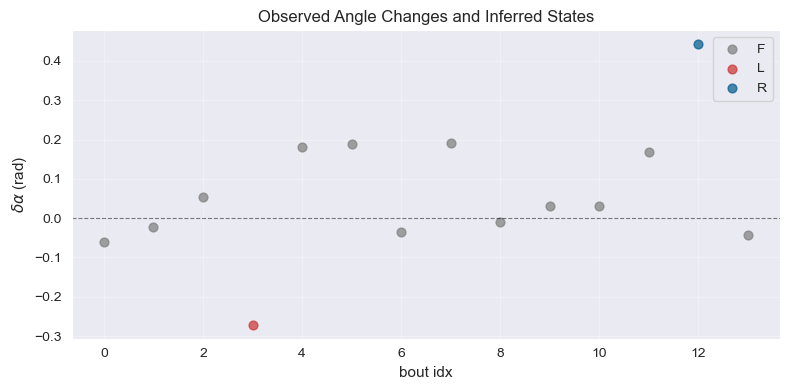

In [11]:
### Question 3a Solution

def plot_states_scatter(delta_alpha, inferred_states, state_names=state_names, state_colors=state_colors):
    """
    Plot delta_alpha colored by inferred_states and print occupancy stats.

    Returns (fig, ax, counts_array)
    """
    delta_alpha = np.asarray(delta_alpha)
    inferred_states = np.asarray(inferred_states)

    if delta_alpha.shape[0] != inferred_states.shape[0]:
        raise ValueError("`delta_alpha` and `inferred_states` must have the same length")

    n_states = len(state_names)
    fig, ax = plt.subplots(figsize=(8,4))

    for state_idx in range(n_states):
        mask = inferred_states == state_idx
        ax.scatter(np.where(mask)[0], delta_alpha[mask],
                   c=state_colors[state_idx], label=state_names[state_idx],
                   alpha=0.7, s=40)

    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_ylabel(r'$\delta\alpha$ (rad)', fontsize=11)
    ax.set_xlabel('bout idx', fontsize=11)
    ax.set_title('Observed Angle Changes and Inferred States', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)
    plt.tight_layout()

    return

plot_states_scatter(d_alpha_fish, inferred_states)


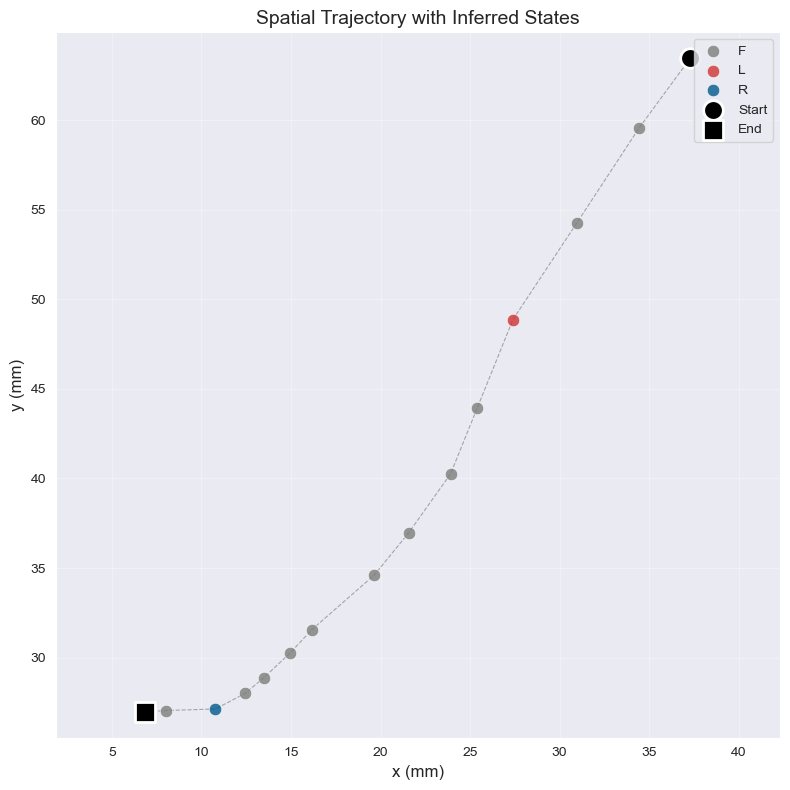


Trajectory Statistics
Total displacement: 47.54 mm
Total path length: 49.61 mm
Number of bouts (with states): 14
Average bout distance: 3.54 mm
Turn bias: L=1, R=1
Left turn percentage: 50.0%


In [12]:
def plot_trajectory_with_states(df_fish, inferred_states, state_names=state_names, state_colors=state_colors):
    """
    Plot spatial trajectory with bouts colored by inferred states and print stats.

    `inferred_states` has length T-1 (one per delta_alpha).
    Bout positions: x[0] has no state, x[1] corresponds to inferred_states[0], etc.
    """
    x = np.asarray(df_fish['x'].values)
    y = np.asarray(df_fish['y'].values)
    inferred_states = np.asarray(inferred_states)

    # Check alignment: x has T bouts, inferred_states has T-1 states
    if x.shape[0] != inferred_states.shape[0] + 1:
        raise ValueError(f"Length mismatch: x has {x.shape[0]} bouts, "
                        f"but inferred_states has {inferred_states.shape[0]} states. "
                        f"Expected {x.shape[0]-1} states.")

    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot full trajectory
    ax.plot(x, y, 'k--', alpha=0.3, linewidth=0.8, zorder=1)

    for state_idx, (name, color) in enumerate(zip(state_names, state_colors)):
        # Color refers to the previous time point: marker at (x[i], y[i]) uses inferred_states[i-1],
        # so we plot positions x[:-1], y[:-1] colored by inferred_states
        mask = inferred_states == state_idx
        ax.scatter(x[:-1][mask], y[:-1][mask], c=color, label=name,
                   s=80, alpha=0.8, edgecolors='white', linewidth=0.5, zorder=2)

    # Mark start
    ax.scatter(x[0], y[0], marker='o', s=200, c='black',
               label='Start', edgecolors='white', linewidth=2, zorder=3)

    # Mark end
    ax.scatter(x[-1], y[-1], marker='s', s=200, c='black',
               label='End', edgecolors='white', linewidth=2, zorder=3)

    ax.set_xlabel('x (mm)', fontsize=12)
    ax.set_ylabel('y (mm)', fontsize=12)
    ax.set_title('Spatial Trajectory with Inferred States', fontsize=14)
    ax.legend(loc='best', fontsize=10)
    ax.grid(alpha=0.3)
    ax.axis('equal')
    plt.tight_layout()

    plt.show()

    # Statistics
    steps = np.hypot(np.diff(x), np.diff(y))
    displacement = np.hypot(x[-1] - x[0], y[-1] - y[0])
    path_length = float(np.sum(steps))
    n_bouts = int(len(inferred_states))
    avg_bout_dist = float(np.mean(steps)) if steps.size > 0 else 0.0

    left_bouts = int(np.sum(inferred_states == 1))
    right_bouts = int(np.sum(inferred_states == 2))
    turn_total = left_bouts + right_bouts
    left_pct = (100.0 * left_bouts / turn_total) if turn_total > 0 else None

    sep = '=' * 60
    print(f"\n{sep}\nTrajectory Statistics\n{sep}")
    print(f"Total displacement: {displacement:.2f} mm")
    print(f"Total path length: {path_length:.2f} mm")
    print(f"Number of bouts (with states): {n_bouts}")
    print(f"Average bout distance: {avg_bout_dist:.2f} mm")
    print(sep)
    print(f"Turn bias: L={left_bouts}, R={right_bouts}")
    if left_pct is not None:
        print(f"Left turn percentage: {left_pct:.1f}%")
    print(sep)

    return

fish_df = fish_bouts[fish_bouts.fish_idx == 0]
plot_trajectory_with_states(fish_df, inferred_states)


Running Viterbi algorithm on fish 10...

Fish idx = 10 
Total time steps: 289

State occupancy:
  F       :  195 bouts ( 67.5%)
  L       :   51 bouts ( 17.6%)
  R       :   43 bouts ( 14.9%)

Detailed inference for first 10 time steps:
------------------------------------------------------------
   # |   δα (rad) |   Inferred
------------------------------------------------------------
   0 |     0.0715 |          F
   1 |     0.0901 |          F
   2 |     0.2093 |          R
   3 |     0.7380 |          R
   4 |     2.5114 |          R
   5 |     1.4776 |          R
   6 |     1.0403 |          R
   7 |     0.7218 |          R
   8 |    -0.3714 |          L
   9 |    -0.0084 |          F


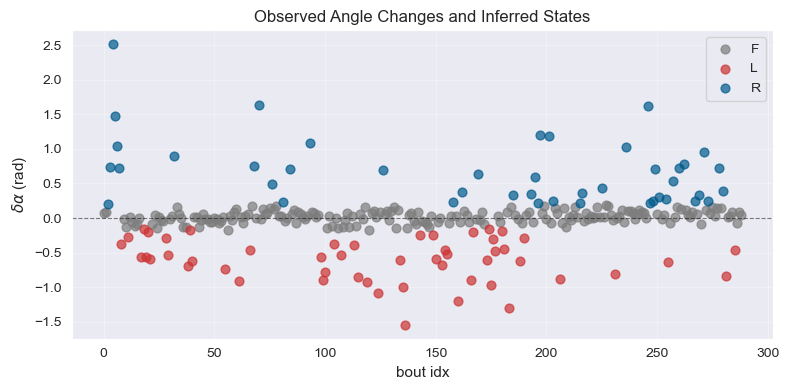

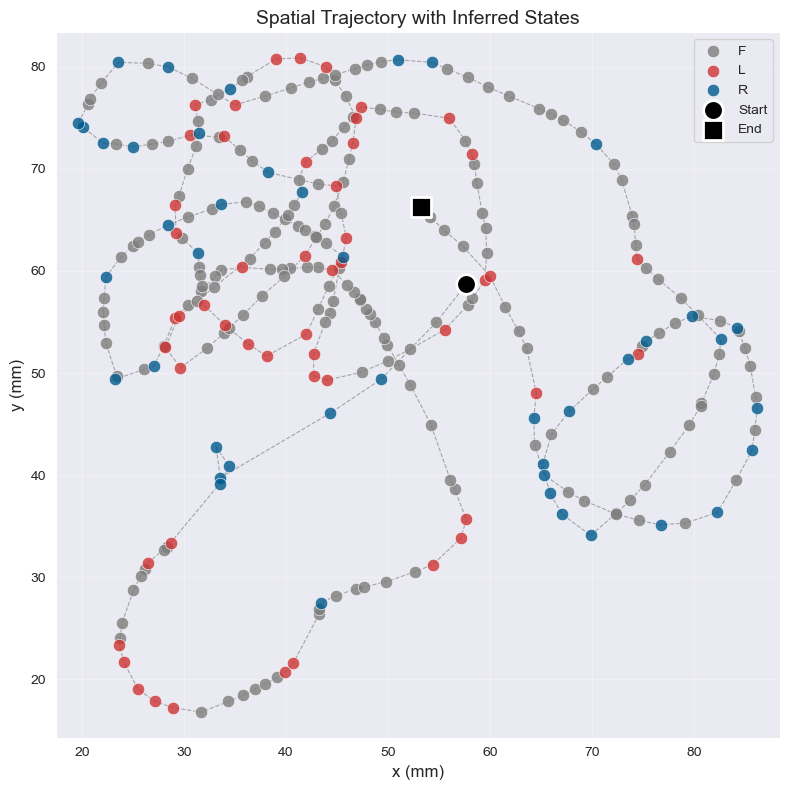


Trajectory Statistics
Total displacement: 8.77 mm
Total path length: 621.60 mm
Number of bouts (with states): 289
Average bout distance: 2.15 mm
Turn bias: L=51, R=43
Left turn percentage: 54.3%


In [13]:
def decode_trajectory(fish_bouts, fish_idx, verbose=True):
    """
    Decode and visualize a single fish trajectory.

    Steps:
    - compute per-bout heading changes (delta alpha)
    - compute emission probabilities for each delta
    - run the Viterbi decoder to infer hidden states
    - optionally print a numeric report
    - plot angle-change scatter and spatial trajectory colored by inferred states

    Parameters
    ----------
    fish_bouts : pd.DataFrame
        Long-format DataFrame with columns including `fish_idx`, `x`, `y`, `alpha`.
    fish_idx : int
        Index of the fish to decode.
    verbose : bool, optional
        If True print a summary report (default: True).
    """
    # Compute delta angles for the selected fish (length = number of bouts - 1)
    d_alpha_fish = get_fish_delta_alpha_array(fish_bouts, fish_idx)

    # Compute emission probabilities for each delta angle and each state (shape: T-1 × 3)
    E = compute_emission_probs(d_alpha_fish, sigma_F, sigma_T)

    # Run the Viterbi algorithm to infer the most likely state sequence
    print(f"Running Viterbi algorithm on fish {fish_idx}...")
    inferred_states = viterbi(E, omega, initial_state=None)

    # If requested, print occupancy stats and a short per-step listing
    if verbose:
        report_viterbi(d_alpha_fish, inferred_states, fish_idx)

    # Extract the original per-bout dataframe for this fish (has one extra row vs. d_alpha)
    fish_df = fish_bouts[fish_bouts.fish_idx == fish_idx]

    # Plot delta_alpha points colored by inferred state (alignment: inferred_states[i] ↔ delta at bout i+1)
    plot_states_scatter(d_alpha_fish, inferred_states)

    # Plot spatial trajectory with bout markers colored by inferred state
    # Note: plot_trajectory_with_states expects inferred_states length = len(x) - 1
    plot_trajectory_with_states(fish_df, inferred_states)

fish_idx = 10
decode_trajectory(fish_bouts, fish_idx, verbose=True)